# 👥 InsuraSight — Notebook 03 : Clustering & Détection de Fraude

**Partie A — Segmentation clients** : K-Means (4 clusters) + UMAP 2D

**Partie B — Détection de fraude** : Isolation Forest + règles métier combinées

> **Pré-requis** : `02_modeling.ipynb` doit avoir été exécuté (modèles dans `models/`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score, davies_bouldin_score
from sklearn.ensemble      import IsolationForest
from sklearn.decomposition import PCA
import umap

warnings.filterwarnings("ignore")
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
SEED = 42; np.random.seed(SEED)

COLORS = {"primary":"#1B4F72","secondary":"#2E86C1","accent":"#E74C3C",
          "success":"#27AE60","warn":"#F39C12","neutral":"#5D6D7E"}
CLUSTER_COLORS = ["#1B4F72","#27AE60","#F39C12","#E74C3C"]
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})
print("✅ Imports OK")

✅ Imports OK


## Partie A — Segmentation clients

### Préparation du profil client agrégé

In [2]:
df_clients  = pd.read_csv("data/raw/clients.csv")
df_polices  = pd.read_csv("data/raw/polices.csv")
df_sinistres= pd.read_csv("data/raw/sinistres.csv", parse_dates=["date_survenance"])

sin_cli = (df_sinistres.groupby("client_id")
           .agg(nb_sinistres_total=("sinistre_id","count"),
                montant_total=("montant_indemnise","sum"),
                montant_moy=("montant_indemnise","mean"),
                nb_litigieux=("statut", lambda x: (x=="Litigieux").sum()))
           .reset_index())

pol_cli = (df_polices.groupby("client_id")
           .agg(nb_polices=("police_id","count"),
                prime_totale=("prime_annuelle","sum"),
                prime_moy=("prime_annuelle","mean"),
                nb_produits_diff=("type_produit","nunique"))
           .reset_index())

profil = df_clients.merge(pol_cli, on="client_id", how="left").merge(sin_cli, on="client_id", how="left")
for col in ["nb_sinistres_total","montant_total","montant_moy","nb_litigieux"]:
    profil[col] = profil[col].fillna(0)

profil["freq_sin_par_police"]  = profil["nb_sinistres_total"] / profil["nb_polices"].clip(lower=1)
profil["taux_litigieux"]       = profil["nb_litigieux"] / profil["nb_sinistres_total"].clip(lower=1)
profil["ratio_sinistre_prime"] = profil["montant_total"] / profil["prime_totale"].clip(lower=1)

print(f"Profil clients : {profil.shape}")
profil.describe().round(2)

Profil clients : (5000, 19)


,age,anciennete_annees,nb_sinistres_passes,score_risque_init,nb_polices,prime_totale,prime_moy,nb_produits_diff,nb_sinistres_total,montant_total,montant_moy,nb_litigieux,freq_sin_par_police,taux_litigieux,ratio_sinistre_prime
count,5000.00,5000.00,5000.00,5000.00,3819.00,3819.00,3819.00,3819.00,5000.00,5000.00,5000.00,5000.00,3819.00,5000.00,3819.00
mean,41.90,3.43,0.61,0.14,1.89,2849.79,1514.20,1.49,0.62,3264.91,1988.36,0.05,0.43,0.03,1.52
std,13.45,3.83,0.79,0.11,1.01,1773.23,555.20,0.62,1.01,8105.76,4910.00,0.22,0.58,0.14,3.60
min,18.00,0.00,0.00,0.01,1.00,389.00,389.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,1.00,0.00,0.05,1.00,1450.50,1123.83,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,42.00,2.00,0.00,0.13,2.00,2482.00,1434.50,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,51.00,5.00,1.00,0.22,2.00,3780.50,1806.33,2.00,1.00,2456.00,1858.08,0.00,0.75,0.00,1.53
max,85.00,20.00,5.00,0.62,7.00,12138.00,4172.00,3.00,9.00,100715.00,86227.00,3.00,5.00,1.00,56.39


### Choix du K optimal (Elbow + Silhouette)

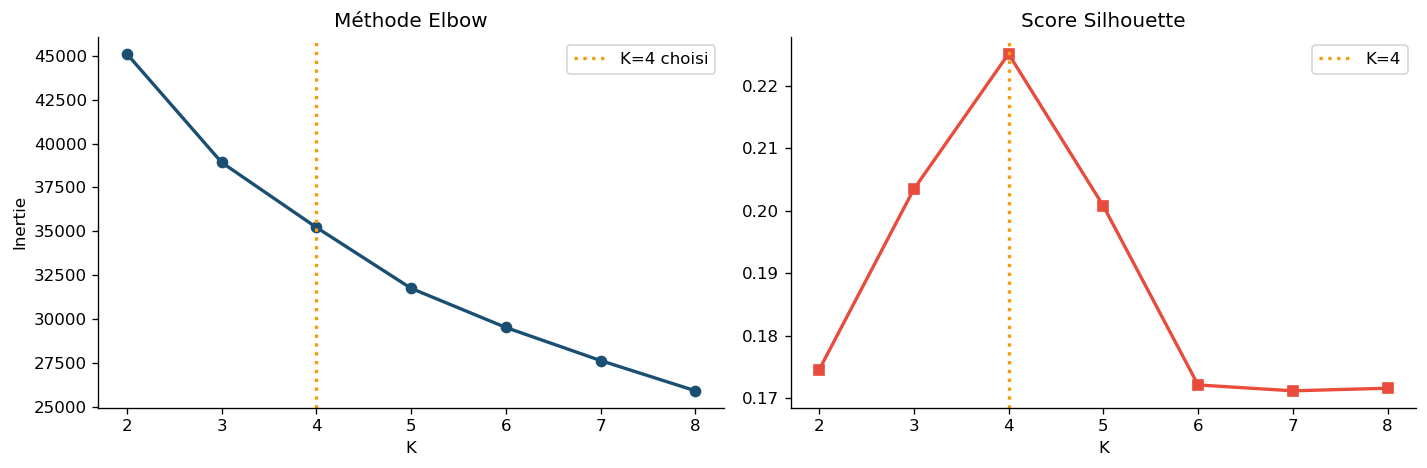

Silhouette K=4 : 0.2251


In [3]:
CLUSTER_FEATURES = [
    "score_risque_init","age","anciennete_annees","nb_sinistres_passes",
    "nb_polices","nb_produits_diff","prime_moy",
    "freq_sin_par_police","montant_moy","taux_litigieux","ratio_sinistre_prime",
]

X_clust = profil[CLUSTER_FEATURES].fillna(0)
scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(X_clust)

k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-", color=COLORS["primary"], linewidth=2)
axes[0].axvline(4, color=COLORS["warn"], linestyle=":", linewidth=2, label="K=4 choisi")
axes[0].set_title("Méthode Elbow"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, "s-", color=COLORS["accent"], linewidth=2)
axes[1].axvline(4, color=COLORS["warn"], linestyle=":", linewidth=2, label="K=4")
axes[1].set_title("Score Silhouette"); axes[1].set_xlabel("K")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Silhouette K=4 : {silhouettes[2]:.4f}")

### K-Means final (K=4) + UMAP

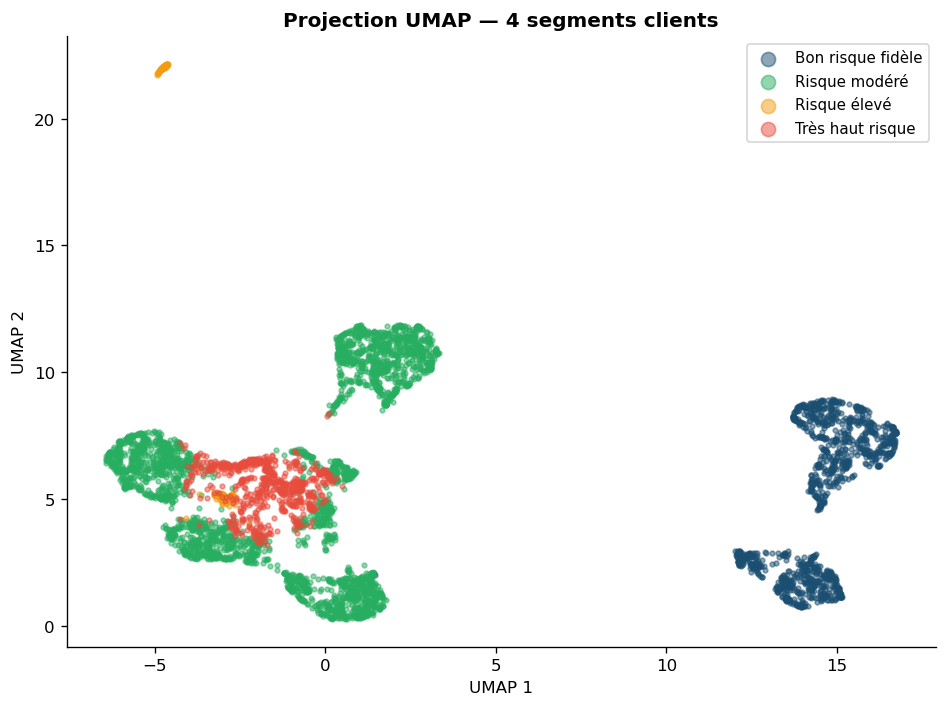


Profil par segment :


,score_risque_init,freq_sin_par_police,ratio_sinistre_prime
segment,,,
🔴 Très haut risque,0.190,1.207,6.728
🔵 Risque modéré,0.132,0.243,0.352
🟠 Risque élevé,0.175,0.847,2.500
🟢 Bon risque fidèle,0.145,0.000,0.000


In [4]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20, max_iter=500)
profil["cluster"] = kmeans.fit_predict(X_scaled)

# Labels métier
cluster_profiles = profil.groupby("cluster")[CLUSTER_FEATURES].mean()
risk_rank = (cluster_profiles["score_risque_init"] + cluster_profiles["freq_sin_par_police"]).argsort()
labels_ordered = ["🟢 Bon risque fidèle","🔵 Risque modéré","🟠 Risque élevé","🔴 Très haut risque"]
CLUSTER_LABELS = {int(cid): lbl for cid, lbl in zip(risk_rank.values, labels_ordered)}
profil["segment"] = profil["cluster"].map(CLUSTER_LABELS)

# UMAP
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=SEED, n_jobs=1)
X_2d = reducer.fit_transform(X_scaled)
profil["umap_x"] = X_2d[:,0]; profil["umap_y"] = X_2d[:,1]

# Plot UMAP
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cid, lbl) in enumerate(CLUSTER_LABELS.items()):
    mask = profil["cluster"] == cid
    ax.scatter(profil.loc[mask,"umap_x"], profil.loc[mask,"umap_y"],
               s=8, alpha=0.5, color=CLUSTER_COLORS[i], label=lbl.split(" ",1)[1])
ax.set_title(f"Projection UMAP — {K} segments clients", fontsize=12, fontweight="bold")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout(); plt.show()

profil.to_csv("data/processed/profil_clients_segments.csv", index=False)
print("\nProfil par segment :")
profil.groupby("segment")[["score_risque_init","freq_sin_par_police","ratio_sinistre_prime"]].mean().round(3)

## Partie B — Détection de Fraude (Isolation Forest)

In [5]:
df_pol  = pd.read_csv("data/raw/polices.csv")
df_sin_feat = (df_sinistres
    .merge(df_clients[["client_id","age","anciennete_annees","nb_sinistres_passes","score_risque_init"]], on="client_id")
    .merge(df_pol[["police_id","prime_annuelle"]], on="police_id"))

df_sin_feat["ratio_reclame_indem"] = df_sin_feat["montant_reclame"] / df_sin_feat["montant_indemnise"].clip(lower=1)
df_sin_feat["ratio_sin_prime"]     = df_sin_feat["montant_reclame"] / df_sin_feat["prime_annuelle"].clip(lower=1)

FRAUD_FEATURES = ["montant_reclame","montant_indemnise","ratio_reclame_indem","ratio_sin_prime",
                  "delai_declaration_j","nb_jours_traitement","age","anciennete_annees",
                  "nb_sinistres_passes","score_risque_init"]

X_fraud = df_sin_feat[FRAUD_FEATURES].fillna(0)
scaler_fraud = StandardScaler()
X_fraud_scaled = scaler_fraud.fit_transform(X_fraud)

iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED, n_jobs=-1)
iso_forest.fit(X_fraud_scaled)

df_sin_feat["anomaly_score"]  = -iso_forest.score_samples(X_fraud_scaled)
df_sin_feat["flag_fraude_ml"] = (iso_forest.predict(X_fraud_scaled) == -1).astype(int)

# Règles métier
df_sin_feat["score_regles"] = (
    (df_sin_feat["montant_reclame"] > df_sin_feat["montant_reclame"].quantile(0.95)).astype(int) * 3 +
    (df_sin_feat["delai_declaration_j"] <= 1).astype(int) * 2 +
    (df_sin_feat["nb_sinistres_passes"] >= 3).astype(int) * 2 +
    (df_sin_feat["ratio_reclame_indem"] > 1.5).astype(int) * 3
)
df_sin_feat["flag_priorite_haute"] = ((df_sin_feat["flag_fraude_ml"]==1) & (df_sin_feat["score_regles"]>=3)).astype(int)

n_sus = df_sin_feat["flag_fraude_ml"].sum()
n_pri = df_sin_feat["flag_priorite_haute"].sum()
cout_normal  = df_sin_feat[df_sin_feat["flag_fraude_ml"]==0]["montant_indemnise"].mean()
cout_suspect = df_sin_feat[df_sin_feat["flag_fraude_ml"]==1]["montant_indemnise"].mean()

print(f"Sinistres analysés      : {len(df_sin_feat):,}")
print(f"Suspects (ML)           : {n_sus:,}  ({n_sus/len(df_sin_feat):.2%})")
print(f"Priorité haute          : {n_pri:,}")
print(f"Coût moyen normal       : {cout_normal:,.0f} €")
print(f"Coût moyen suspect      : {cout_suspect:,.0f} € (×{cout_suspect/cout_normal:.1f})")
print(f"Gain potentiel estimé   : {df_sin_feat[df_sin_feat['flag_fraude_ml']==1]['montant_indemnise'].sum()*0.30:,.0f} €")

Sinistres analysés      : 3,123
Suspects (ML)           : 157  (5.03%)
Priorité haute          : 118
Coût moyen normal       : 4,155 €
Coût moyen suspect      : 25,491 € (×6.1)
Gain potentiel estimé   : 1,200,606 €


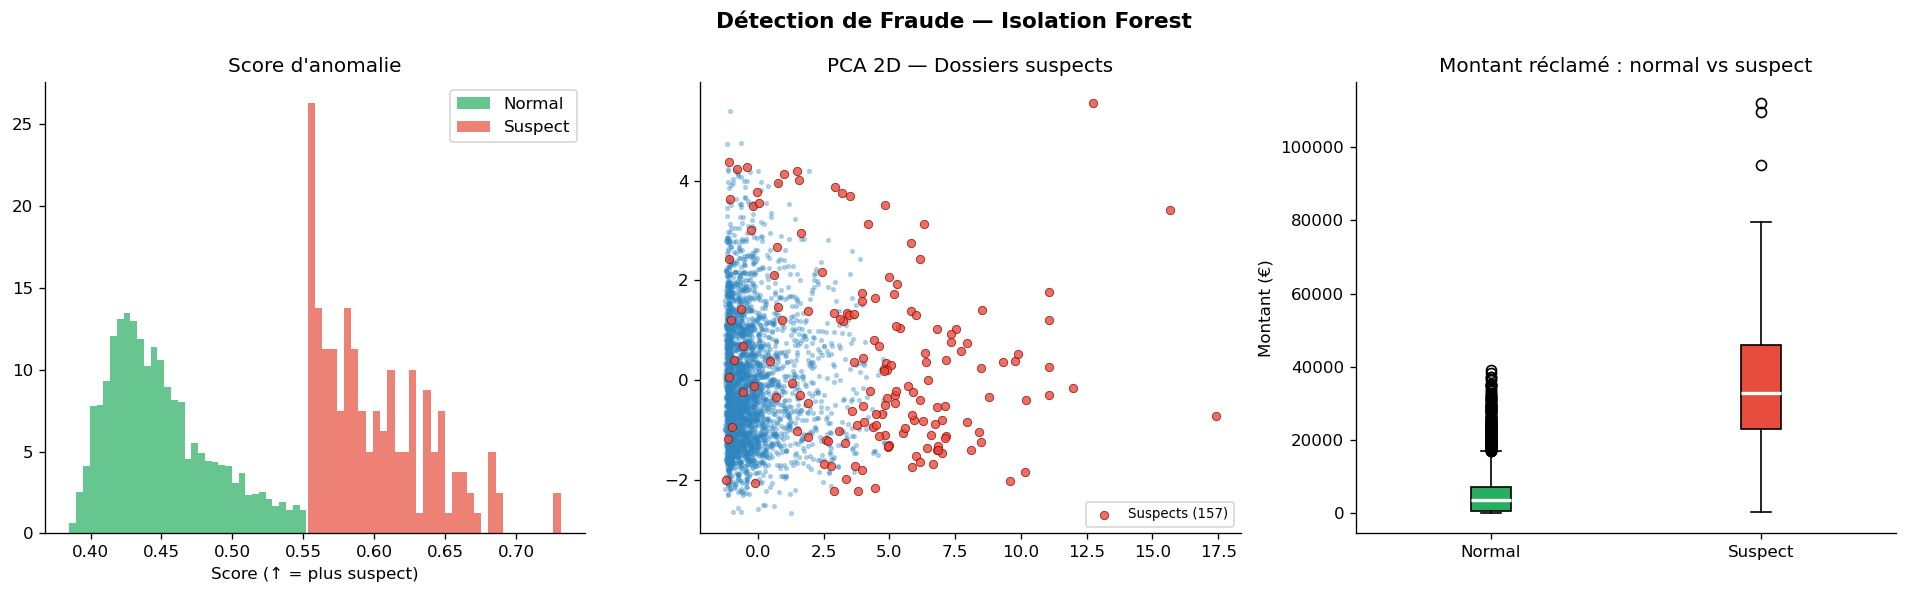


✅ Clustering + détection fraude terminés


In [6]:
# Visualisation fraude
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Détection de Fraude — Isolation Forest", fontsize=13, fontweight="bold")

# Score anomalie
axes[0].hist(df_sin_feat[df_sin_feat["flag_fraude_ml"]==0]["anomaly_score"],
             bins=35, alpha=0.7, color=COLORS["success"], label="Normal", density=True)
axes[0].hist(df_sin_feat[df_sin_feat["flag_fraude_ml"]==1]["anomaly_score"],
             bins=35, alpha=0.7, color=COLORS["accent"],  label="Suspect", density=True)
axes[0].set_title("Score d'anomalie"); axes[0].set_xlabel("Score (↑ = plus suspect)")
axes[0].legend()

# PCA 2D
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_fraud_scaled)
nm = df_sin_feat["flag_fraude_ml"]==0; su = df_sin_feat["flag_fraude_ml"]==1
axes[1].scatter(X_pca[nm,0], X_pca[nm,1], s=5, alpha=0.3, color=COLORS["secondary"])
axes[1].scatter(X_pca[su,0], X_pca[su,1], s=25, alpha=0.8, color=COLORS["accent"],
               edgecolors="darkred", linewidths=0.5, zorder=5, label=f"Suspects ({n_sus})")
axes[1].set_title("PCA 2D — Dossiers suspects"); axes[1].legend(fontsize=8)

# Boxplot montant
bp = axes[2].boxplot(
    [df_sin_feat[df_sin_feat["flag_fraude_ml"]==0]["montant_reclame"].values,
     df_sin_feat[df_sin_feat["flag_fraude_ml"]==1]["montant_reclame"].values],
    patch_artist=True, labels=["Normal","Suspect"],
    medianprops={"color":"white","linewidth":2})
bp["boxes"][0].set_facecolor(COLORS["success"])
bp["boxes"][1].set_facecolor(COLORS["accent"])
axes[2].set_title("Montant réclamé : normal vs suspect")
axes[2].set_ylabel("Montant (€)")

plt.tight_layout(); plt.show()
df_sin_feat.to_csv("data/processed/sinistres_scores_fraude.csv", index=False)
print("\n✅ Clustering + détection fraude terminés")